# Fitting a Cable from 1 to 10 GHz (Part 1)

This tutorial demonstrates an end-to-end workflow for fitting a physically-motivated model to a high-frequency (1 to 10 GHz) measurement of a 1.5 ft `CBN-1.5FT-SMSM` cable from Mini-Circuits. The cable's datasheet is available at `https://www.minicircuits.com/pdfs/CBN-xx-SMSM+.pdf`.

We will start by fitting an ideal transmission line model, and then add losses and parasitics to cater for effects such as attenuation and connector mismatch. The tutorial can be followed either directly in the documentation, or as port of a Jupyter notebook under docs/tutorials.

Note that this is part 1 of a two-part tutorial. Part 2 (Bayesian inference) will be added soon.

## 1. Setting up the environment

We only need a few packages for this tutorial. Make sure the following all import correctly:

In [1]:
import matplotlib.pyplot as plt     # for plotting
import skrf as rf                   # for touchstone reading
import pmrf as prf                  # ParamRF

## 2. Preparing the data

We begin by loading the measurement data. For this tutorial, we will download a sample `.s2p` file directly from the ParamRF repository and load it into a `scikit-rf` Network. The original file as available at https://www.minicircuits.com/WebStore/dashboard.html?model=CBN-1.5FT-SMSM%2B

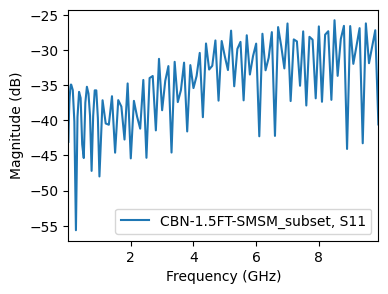

In [2]:
import os
import urllib.request
import skrf as rf
import matplotlib.pyplot as plt

base_url = "https://raw.githubusercontent.com/gvcallen/paramrf/main/docs/tutorials/data/"
file_name = "CBN-1.5FT-SMSM.s2p"
full_url = base_url + file_name
local_dir = "data"
local_filename = os.path.join(local_dir, file_name) 

os.makedirs(local_dir, exist_ok=True)
if not os.path.exists(local_filename):
    print(f"Downloading {file_name} to {local_dir}/...")
    urllib.request.urlretrieve(full_url, local_filename)

# Load the measured data into skrf using the new local path
measured = rf.Network(local_filename, f_unit='GHz')
measured = measured[measured.frequency.f_scaled < 10]
fig, ax = plt.subplots(figsize=(4, 3))
measured.plot_s_db(m=0, n=0, ax=ax)

## 3. Selecting a model

ParamRF provides a few transmission line models, such as ``PhysicalLine``, ``CoaxialLine`` and ``DatasheetLine``. Looking at the datasheet, we see no mention of physical parameters like loss tangent, conductor loss or detailed geometry dimensions. However, there is a velocity factor, as well as loss factors ``k1`` and ``k2``. This is just what ``DatasheetLine`` was meant for.

Let's try fitting the model with its expected length and default parameters as a quick check.

SciPy L-BFGS-B:   0%|          | 0/1024 [00:00<?, ?it/s]

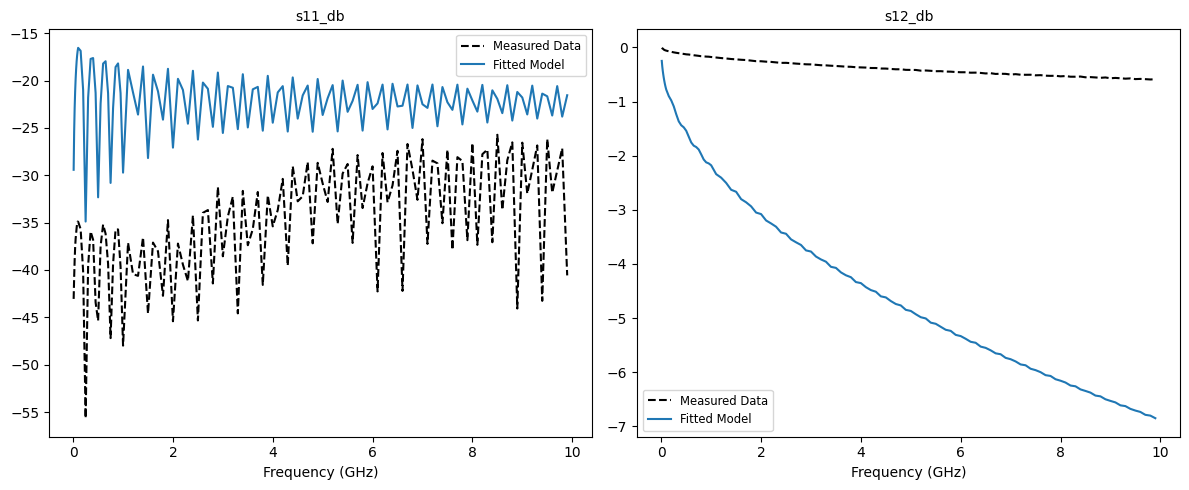

In [3]:
default_model = prf.models.DatasheetLine(length=prf.math.feet_2_meter(1.5))
default_results = prf.fitting.fit(default_model, measured)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
default_results.plot_s_db(m=0, n=0, ax=ax1)
_ = default_results.plot_s_db(m=1, n=0, ax=ax2)

...not horrible, but we can definitely do better by providing the optimizer with a better starting point.

## 4. Specifying parameters

In ParamRF, parameter bounds and scales can be specified using methods such as ``pmrf.Bounded`` or ``pmrf.Fixed`` (available in ``pmrf.parameters``). In this example, we use ``pmrf.Bounded``.

Looking at the datasheet, we find the cable is 50 ohm with a velocity factor `vf` of 0.74, skin effect loss `k1` of around 1.137 dbB/100m, and dielectric loss `k2` of around 0.00253 dB/100m. We use this information directly to specify initial parameters for `DatasheetLine`. We fix the velocity factory (dielectric constant), since there is a known correlation between it and the cable's length (explored further in part 2 of this tutorial!).

We fit the model using both the gradient-based `L-BFGS-B` as well as the robust `Nelder-Mead` (which can work better when you are unsure of your initial parameters).

SciPy L-BFGS-B:   0%|          | 0/1024 [00:00<?, ?it/s]

SciPy Nelder-Mead:   0%|          | 0/1024 [00:00<?, ?it/s]

/home/gvcallen/Masters/Python/.venv/lib/python3.12/site-packages/jaxopt/_src/scipy_wrappers.py:343: RuntimeWarning: Method Nelder-Mead does not use gradient information (jac).
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


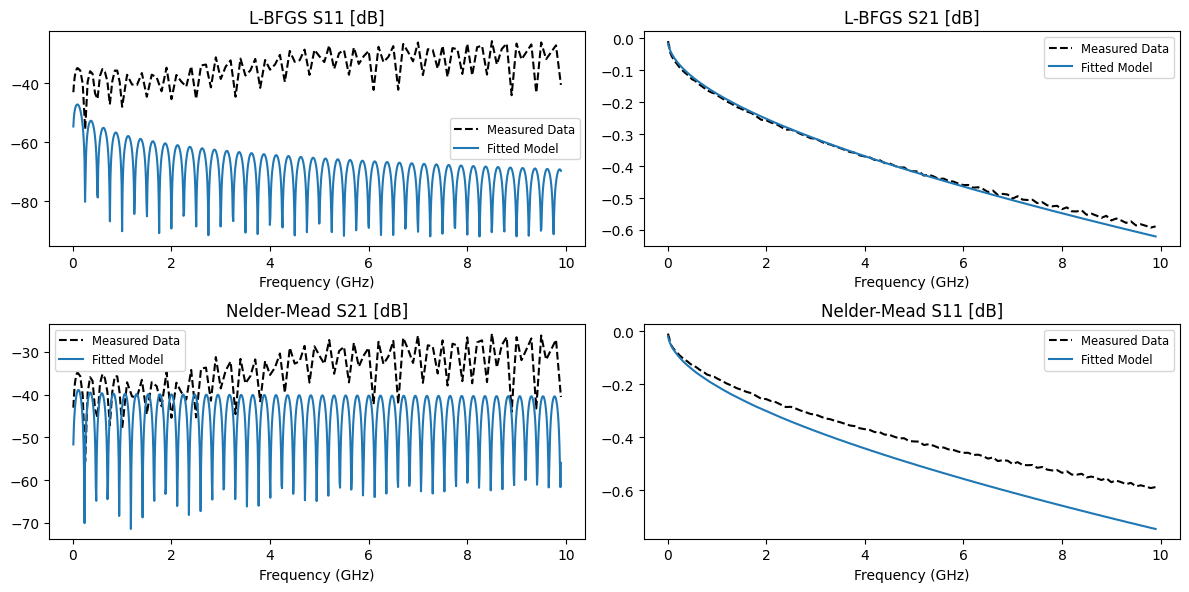

In [4]:
from pmrf.optimize import ScipyMinimize

# Specify prior model parameters
baseline_model = prf.models.DatasheetLine(
    length=prf.Bounded(prf.math.feet_2_meter(1.4), prf.math.feet_2_meter(1.6)),
    zn=prf.Bounded(45.0, 55.0),
    vf=prf.Fixed(0.74),
    k1=prf.Bounded(1.0, 1.3),
    k2=prf.Bounded(2.0, 3.0, scale=1e-3),
)
# Fit the model
baseline_lbfgs_results = prf.fitting.fit(baseline_model, measured, solver=ScipyMinimize(method='L-BFGS-B'))
baseline_nelder_results = prf.fitting.fit(baseline_model, measured, solver=ScipyMinimize(method='Nelder-Mead'))

# Plot the results. We pass a separate frequency to plot the model at a higher resolution
freq_plot = prf.Frequency(
    measured.frequency.f_scaled[0],
    measured.frequency.f_scaled[-1],
    1001,
    'GHz',
)
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
baseline_lbfgs_results.plot_s_db(m=0, n=0, ax=axes[0,0], model_frequency=freq_plot)
baseline_lbfgs_results.plot_s_db(m=1, n=0, ax=axes[0,1], model_frequency=freq_plot)
baseline_nelder_results.plot_s_db(m=0, n=0, ax=axes[1,0], model_frequency=freq_plot)
_ = baseline_nelder_results.plot_s_db(m=1, n=0, ax=axes[1,1], model_frequency=freq_plot)
axes[0,0].set_title('L-BFGS S11 [dB]')
axes[0,1].set_title('L-BFGS S21 [dB]')
axes[1,0].set_title('Nelder-Mead S21 [dB]')
_ = axes[1,1].set_title('Nelder-Mead S11 [dB]')

While Nelder-Mead appears to fit the S11 better, L-BFGS-B achieves a better S21 fit. This can easily be affected by the type of loss function, parameter starting point, the specifical model, as well as many other factors, so it is important to experiment. However, do note that L-BFGS-B is generally much faster since it obtained gradients directly from JAX, which may be more important for large models.

## 5. Adding parasitics

Now that we know that we are in the right ballpark with our initial parameters and Nelder-Mead is working for us, it is clear that S11 drifts over frequency. This can be explained by parasitic capacitance in the cable connectors. We should model this!

To polish this tutorial off, we therefore add two shunt capacitors to both sides of the cable model using the `**` operator.

We print out the composite model before continuing to view its parameters.

In [5]:
# Define a parasitic connector capacitor
# We initialize it at 0.1 pF and constrain it to physical (positive) values
shunt_cap1 = prf.models.ShuntCapacitor(
    C=prf.Bounded(0.0, 1.0, value=0.1, scale=1e-12), 
)
shunt_cap2 = prf.models.ShuntCapacitor(
    C=prf.Bounded(0.0, 1.0, value=0.1, scale=1e-12), 
)

# Create the composite model by cascading Cap -> Coax -> Cap
composite_model = shunt_cap1 ** baseline_model ** shunt_cap2

print("Composite Model:")
composite_model

Composite Model:


Cascade(
  models=[
    ShuntCapacitor(C=1.e-13),
    DatasheetLine(length=0.4572, zn=50., vf=0.74, k1=1.15, k2=0.0025),
    ShuntCapacitor(C=1.e-13)
  ]
)

## 6. Final optimization

Finally, we optimize the composite model and print out its best parameters. The model captures the high-frequency drift extremely well, while maintaining reasonable parameter values.

SciPy Nelder-Mead:   0%|          | 0/1024 [00:00<?, ?it/s]

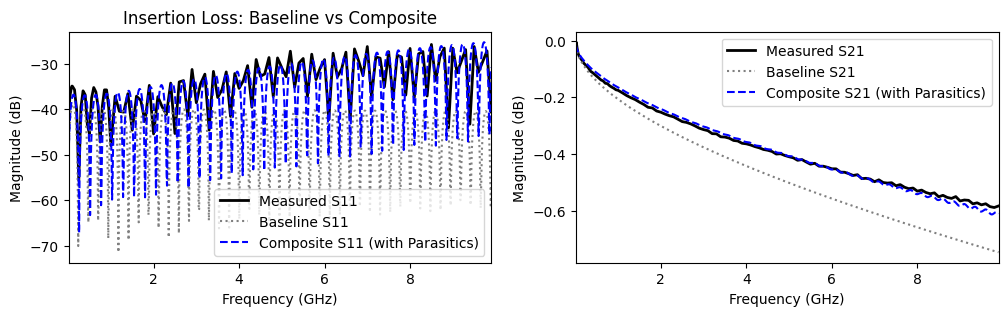

Final Model:


Cascade(
  models=[
    ShuntCapacitor(C=1.8659e-14),
    DatasheetLine(length=0.4435, zn=50.7087, vf=0.74, k1=1.0866, k2=0.0029),
    ShuntCapacitor(C=1.8239e-14)
  ]
)

In [6]:
# Fit the composite model
results_composite = prf.fitting.fit(composite_model, measured, solver=ScipyMinimize(method='Nelder-Mead'))
composite_fitted = results_composite.model

# Plot the final comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

measured.plot_s_db(m=0, n=0, ax=ax1, label='Measured S11', color='k', linewidth=2)
baseline_nelder_results.model.plot_s_db(freq_plot, m=0, n=0, ax=ax1, label='Baseline S11', color='gray', linestyle=':')
composite_fitted.plot_s_db(freq_plot, m=0, n=0, ax=ax1, label='Composite S11 (with Parasitics)', color='b', linestyle='--')

measured.plot_s_db(m=1, n=0, ax=ax2, label='Measured S21', color='k', linewidth=2)
baseline_nelder_results.model.plot_s_db(freq_plot, m=1, n=0, ax=ax2, label='Baseline S21', color='gray', linestyle=':')
composite_fitted.plot_s_db(freq_plot, m=1, n=0, ax=ax2, label='Composite S21 (with Parasitics)', color='b', linestyle='--')

ax1.set_title('Return Loss: Baseline vs Composite')
ax1.set_title('Insertion Loss: Baseline vs Composite')
ax1.legend()
plt.show()

# Inspect the final resolved parameters
print("Final Model:")
composite_fitted